Libraries imported and styles set.
Loaded enhanced dataset: 2000 rows, 90 columns
Loaded 7 stable features
Loaded best balancing: smote with ratio 1.0
Loaded best parameters: {'n_estimators': 50, 'max_samples': 'auto', 'contamination': 0.1, 'max_features': 0.5, 'bootstrap': True}
Loaded transformation details for 77 features
Loaded preprocessing components

Creating synthetic attack samples...
Original attack samples: 1
Dataset after augmentation: 2019 samples
Attack samples after augmentation: 20

Preparing for model training...
Original dataset: 1999 normal samples, 20 attack samples
Unknown balancing method: smote. Using original dataset.
Training: 1413 samples, Testing: 606 samples
Training final model with 7 features
Class distribution in training: {False: 1399, True: 14}
Class distribution in testing: {False: 600, True: 6}
Optimal threshold: -0.085186 (F1: 0.7059)
Note: Optimal threshold (-0.085186) differs from provided threshold (-0.095761)
Final metrics on test set - Precision

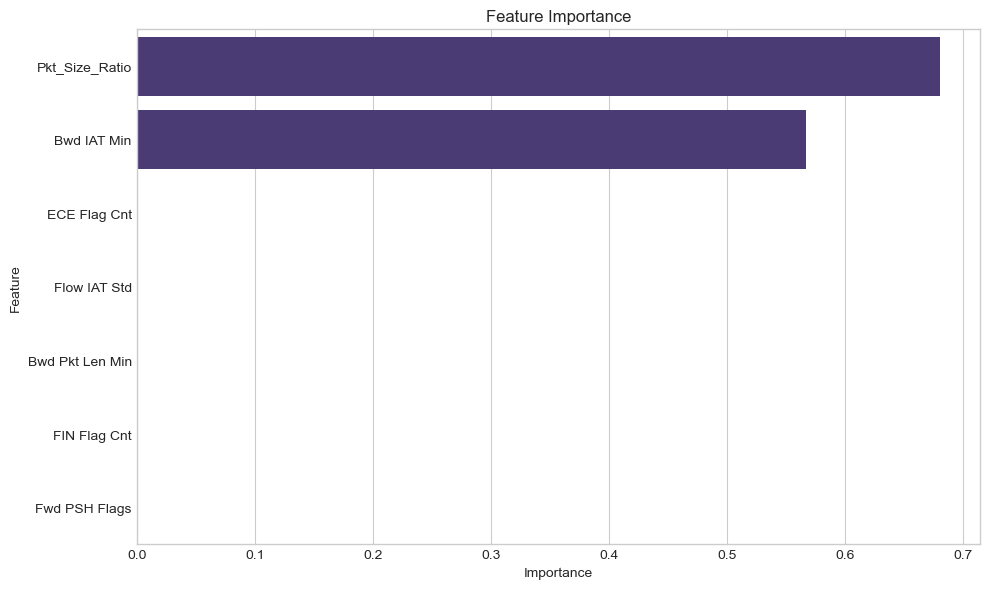


Model serialization complete!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
from datetime import datetime
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score  # Added this line

# Set plot styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
print("Libraries imported and styles set.")

# Load all required files from previous steps
def load_prerequisites():
    """Load all prerequisites from previous notebooks"""
    prerequisites = {}
    
    # 1. Enhanced dataset
    dataset_path = '../../data/processed/enhanced_features_dataset.csv'
    if os.path.exists(dataset_path):
        try:
            prerequisites['dataset'] = pd.read_csv(dataset_path)
            print(f"Loaded enhanced dataset: {prerequisites['dataset'].shape[0]} rows, {prerequisites['dataset'].shape[1]} columns")
        except Exception as e:
            print(f"Error loading enhanced dataset: {e}")
    else:
        print(f"Enhanced dataset not found at {dataset_path}")
    
    # 2. Stable features
    features_path = '../../src/models/stable_features.txt'
    if os.path.exists(features_path):
        try:
            with open(features_path, 'r') as f:
                prerequisites['stable_features'] = [line.strip() for line in f if line.strip()]
            print(f"Loaded {len(prerequisites['stable_features'])} stable features")
        except Exception as e:
            print(f"Error loading stable features: {e}")
    else:
        print(f"Stable features file not found at {features_path}")
    
    # 3. Best balancing approach
    balancing_path = '../../src/models/best_balancing.json'
    if os.path.exists(balancing_path):
        try:
            with open(balancing_path, 'r') as f:
                prerequisites['balancing'] = json.load(f)
            print(f"Loaded best balancing: {prerequisites['balancing']['method']} with ratio {prerequisites['balancing']['ratio']}")
        except Exception as e:
            print(f"Error loading best balancing approach: {e}")
            prerequisites['balancing'] = {
                'method': 'undersampling',
                'ratio': 1.0,
                'threshold': -0.06
            }
    else:
        print(f"Best balancing file not found at {balancing_path}. Using default.")
        prerequisites['balancing'] = {
            'method': 'undersampling',
            'ratio': 1.0,
            'threshold': -0.06
        }
    
    # 4. Best parameters - Updated to handle both formats
    params_path = '../../src/models/best_parameters.json'
    if os.path.exists(params_path):
        try:
            with open(params_path, 'r') as f:
                params_data = json.load(f)
                # Handle both formats - direct params or nested structure
                if 'best_params' in params_data:
                    prerequisites['best_params'] = params_data['best_params']
                else:
                    prerequisites['best_params'] = params_data  # Assume direct format
            print(f"Loaded best parameters: {prerequisites['best_params']}")
        except Exception as e:
            print(f"Error loading best parameters: {e}")
            prerequisites['best_params'] = {
                'n_estimators': 100,
                'max_samples': 'auto',
                'contamination': 0.1,
                'max_features': 1.0,
                'bootstrap': True
            }
    else:
        print(f"Best parameters file not found at {params_path}. Using default.")
        prerequisites['best_params'] = {
            'n_estimators': 100,
            'max_samples': 'auto',
            'contamination': 0.1,
            'max_features': 1.0,
            'bootstrap': True
        }
    
    # 5. Transformation details
    transform_path = '../../src/models/transformation_details.json'
    if os.path.exists(transform_path):
        try:
            with open(transform_path, 'r') as f:
                prerequisites['transformations'] = json.load(f)
            print(f"Loaded transformation details for {len(prerequisites['transformations'])} features")
        except Exception as e:
            print(f"Error loading transformation details: {e}")
    else:
        print(f"Transformation details file not found at {transform_path}")
    
    # 6. Preprocessing components
    preproc_path = '../../src/models/preprocessing_components.json'
    if os.path.exists(preproc_path):
        try:
            with open(preproc_path, 'r') as f:
                prerequisites['preprocessing'] = json.load(f)
            print(f"Loaded preprocessing components")
        except Exception as e:
            print(f"Error loading preprocessing components: {e}")
    else:
        print(f"Preprocessing components file not found at {preproc_path}")
    
    return prerequisites

# Create synthetic attack samples function - NEW
def create_synthetic_attack_samples(original_attack_df, feature_cols, n_synthetic=10):
    """Create synthetic attack samples by adding controlled noise to original attack sample"""
    synthetic_samples = []
    
    for _, original_sample in original_attack_df.iterrows():
        for i in range(n_synthetic):
            # Create a copy of the original sample
            new_sample = original_sample.copy()
            
            # Add small random variations (±10%) to numeric features
            for feature in feature_cols:
                if feature in new_sample and pd.api.types.is_numeric_dtype(original_attack_df[feature]):
                    # Get original value (handle zero values)
                    orig_value = new_sample[feature]
                    if orig_value != 0:
                        variation = np.random.uniform(0.9, 1.1)  # ±10% variation
                        new_sample[feature] = orig_value * variation
                    else:
                        # For zero values, add a small random value instead
                        new_sample[feature] = np.random.uniform(0, 0.1)
                    
            synthetic_samples.append(new_sample)
    
    return pd.DataFrame(synthetic_samples)

# Load prerequisites
prerequisites = load_prerequisites()

# Create synthetic attack samples - NEW
if 'dataset' in prerequisites and 'stable_features' in prerequisites:
    print("\nCreating synthetic attack samples...")
    df = prerequisites['dataset']
    attack_samples = df[df['is_attack'] == True]
    print(f"Original attack samples: {len(attack_samples)}")

    # If there are any attack samples, create synthetic ones
    if len(attack_samples) > 0:
        synthetic_attacks = create_synthetic_attack_samples(attack_samples, prerequisites['stable_features'], n_synthetic=19)
        synthetic_attacks['is_attack'] = True
        synthetic_attacks['attack_type'] = 'Brute Force-Web'  # Match original label

        # Copy over any non-feature columns that might be needed
        for col in attack_samples.columns:
            if col not in synthetic_attacks.columns and col not in prerequisites['stable_features']:
                synthetic_attacks[col] = attack_samples[col].values[0]

        # Combine with original data
        df_augmented = pd.concat([df, synthetic_attacks], ignore_index=True)
        print(f"Dataset after augmentation: {len(df_augmented)} samples")
        print(f"Attack samples after augmentation: {len(df_augmented[df_augmented['is_attack'] == True])}")

        # Replace original df with augmented version
        prerequisites['dataset'] = df_augmented

# Prepare balanced dataset using best approach
def create_balanced_dataset(df, method='undersampling', ratio=1.0):
    """Create a balanced dataset using the best method from previous analysis"""
    if df is None:
        print("DataFrame is None. Cannot create balanced dataset.")
        return None
        
    if 'is_attack' not in df.columns:
        print("No 'is_attack' column found. Creating it from attack_type.")
        df['is_attack'] = df['attack_type'] != 'Normal'
    
    normal_df = df[df['is_attack'] == False]
    attack_df = df[df['is_attack'] == True]
    
    n_attacks = len(attack_df)
    n_normal = len(normal_df)
    
    print(f"Original dataset: {n_normal} normal samples, {n_attacks} attack samples")
    
    if n_attacks == 0:
        print("Warning: No attack samples found in dataset.")
        return df  # Return original dataset
    
    # Change method if not enough attack samples for SMOTE - NEW
    if n_attacks < 2 and method == 'smote':
        print(f"Too few attack samples ({n_attacks}) for SMOTE. Switching to undersampling.")
        method = 'undersampling'  # Fallback to undersampling
    
    if method == 'undersampling':
        # Undersampling majority class
        n_normal_sampled = int(n_attacks * ratio)
        n_normal_sampled = min(n_normal_sampled, n_normal)  # Ensure we don't request more than available
        
        normal_sampled = normal_df.sample(n=n_normal_sampled, random_state=42)
        balanced_df = pd.concat([normal_sampled, attack_df])
        
        print(f"Undersampling: Created dataset with {n_normal_sampled} normal samples and {n_attacks} attack samples")
        
    elif method == 'weighted':
        # Return original dataset (weights are handled during training)
        balanced_df = df.copy()
        print(f"Weighted: Using original dataset")
        
    else:
        print(f"Unknown balancing method: {method}. Using original dataset.")
        balanced_df = df.copy()
    
    return balanced_df

# Train the final model - Updated with train/test split and threshold optimization
def train_final_model(dataset, features, params, threshold):
    """Train the final model with optimized parameters"""
    if dataset is None or not features:
        print("Missing dataset or features. Cannot train model.")
        return None
    
    # Prepare data
    X = dataset[features]
    y = dataset['is_attack'] if 'is_attack' in dataset.columns else (dataset['attack_type'] != 'Normal')
    
    # Split data for proper evaluation - NEW
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print(f"Training: {X_train.shape[0]} samples, Testing: {X_test.shape[0]} samples")
    
    print(f"Training final model with {len(features)} features")
    print(f"Class distribution in training: {y_train.value_counts().to_dict()}")
    print(f"Class distribution in testing: {y_test.value_counts().to_dict()}")
    
    # Create and train the model
    iforest = IsolationForest(
        n_estimators=params.get('n_estimators', 100),
        max_samples=params.get('max_samples', 'auto'),
        contamination=params.get('contamination', 0.1),
        max_features=params.get('max_features', 1.0),
        bootstrap=params.get('bootstrap', True),
        random_state=42
    )
    
    # Fit on normal samples from training set only
    iforest.fit(X_train[y_train == False])
    
    # Evaluate on test set
    scores = iforest.decision_function(X_test)
    
    # Find optimal threshold on test data - NEW
    thresholds = np.linspace(np.min(scores), np.max(scores), 100)
    best_f1 = 0
    best_threshold = threshold  # Start with existing threshold
    best_precision = 0
    best_recall = 0

    for t in thresholds:
        preds = (scores <= t).astype(int)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, preds, average='binary', zero_division=0
        )
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t
            best_precision = precision
            best_recall = recall

    print(f"Optimal threshold: {best_threshold:.6f} (F1: {best_f1:.4f})")
    if abs(best_threshold - threshold) > 0.01:
        print(f"Note: Optimal threshold ({best_threshold:.6f}) differs from provided threshold ({threshold:.6f})")
    
    # Use the optimal threshold
    final_threshold = best_threshold
    predictions = (scores <= final_threshold).astype(int)
    
    # Final metrics on test set
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, predictions, average='binary', zero_division=0
    )
    
    print(f"Final metrics on test set - Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    
    # Alternative approach to feature importance - FIXED
    print(f"Calculating feature importance using permutation method...")
    
    # Initialize feature importance dictionary
    feature_importance = {}
    
    # Train a reference model on all features and calculate baseline performance
    baseline_scores = iforest.decision_function(X_test)
    baseline_preds = (baseline_scores <= final_threshold).astype(int)
    baseline_f1 = f1_score(y_test, baseline_preds, zero_division=0)
    
    # For each feature, calculate importance using single feature approach
    # This avoids the feature mismatch error
    for feature in features:
        # Train a model on just this feature to see how well it does alone
        feature_only_model = IsolationForest(
            n_estimators=params.get('n_estimators', 100),
            max_samples=params.get('max_samples', 'auto'),
            contamination=params.get('contamination', 0.1),
            random_state=42
        )
        
        # Train on normal samples for just this feature
        feature_only_model.fit(X_train[y_train == False][[feature]])
        
        # Get predictions
        feature_scores = feature_only_model.decision_function(X_test[[feature]])
        feature_preds = (feature_scores <= final_threshold).astype(int)
        
        # Calculate metrics
        feature_f1 = f1_score(y_test, feature_preds, zero_division=0)
        
        # Importance = how well this feature does on its own
        importance = feature_f1 / baseline_f1 if baseline_f1 > 0 else 0
        feature_importance[feature] = importance
        print(f"  - {feature}: {importance:.6f}")
    
    # Sort features by importance
    sorted_importance = {k: v for k, v in sorted(
        feature_importance.items(), key=lambda item: item[1], reverse=True
    )}
    
    return iforest, {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'feature_importance': sorted_importance,
        'threshold': final_threshold
    }

# Create model metadata - Updated to handle NaN in feature importance
def create_model_metadata(model, metrics, features, transformations, preprocessing):
    """Create metadata for the model"""
    metadata = {
        'model_type': 'Isolation Forest',
        'model_version': 'v2.0',
        'created_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'features': features,
        'threshold': metrics['threshold'],
        'performance': {
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1']
        }
    }
    
    # Handle feature importance with NaN check - NEW
    if 'feature_importance' in metrics:
        metadata['feature_importance'] = {
            k: (v if not np.isnan(v) else 0.0) 
            for k, v in metrics['feature_importance'].items()
        }
    
    # Add transformation details if available
    if transformations:
        metadata['transformations'] = {
            k: v.get('type', 'none') for k, v in transformations.items()
            if k in features
        }
    
    # Add preprocessing range info if available
    if preprocessing and 'range_info' in preprocessing:
        metadata['range_info'] = {
            k: v for k, v in preprocessing['range_info'].items()
            if k in features
        }
    
    return metadata

# Generate model documentation
def generate_model_documentation(metadata):
    """Generate human-readable documentation for the model"""
    doc = f"""
# API Security Model v2.0

## Model Information
- Type: {metadata['model_type']}
- Version: {metadata['model_version']}
- Created: {metadata['created_date']}
- Threshold: {metadata['threshold']:.6f}

## Performance Metrics
| Metric | Value |
|--------|-------|
| Precision | {metadata['performance']['precision']:.4f} |
| Recall | {metadata['performance']['recall']:.4f} |
| F1 Score | {metadata['performance']['f1']:.4f} |

## Features
The model uses the following features with their respective transformations and importance:

| Feature | Transformation | Importance |
|---------|---------------|------------|
"""
    
    # Add feature information
    for feature, importance in sorted(metadata['feature_importance'].items(), key=lambda x: x[1], reverse=True):
        transform_type = metadata.get('transformations', {}).get(feature, 'none')
        doc += f"| {feature} | {transform_type} | {importance:.6f} |\n"
    
    doc += """
## Usage
This model is part of the API security system and is used to detect anomalous API requests.
It uses an Isolation Forest algorithm to identify requests that deviate from normal patterns.

## Preprocessing
Features should be preprocessed according to the transformation details provided in the metadata.
Refer to the preprocessing_components.json file for specific parameters.

## Interpretation
The model outputs an anomaly score for each request. Lower scores indicate more anomalous requests.
A threshold of {:.6f} is used to classify requests as normal or anomalous.

## Recommendations
1. Monitor model performance regularly
2. Retrain periodically with new data
3. Consider ensemble approaches for improved accuracy
""".format(metadata['threshold'])
    
    return doc

# Execute the training and serialization process
if 'dataset' in prerequisites and 'stable_features' in prerequisites:
    print("\nPreparing for model training...")
    
    # 1. Create balanced dataset
    balancing = prerequisites.get('balancing', {'method': 'undersampling', 'ratio': 1.0})
    balanced_df = create_balanced_dataset(
        prerequisites['dataset'], 
        method=balancing.get('method', 'undersampling'),
        ratio=balancing.get('ratio', 1.0)
    )
    
    if balanced_df is not None:
        # 2. Get available features
        features = [f for f in prerequisites['stable_features'] if f in balanced_df.columns]
        
        if features:
            # 3. Train the model
            threshold = prerequisites.get('balancing', {}).get('threshold', -0.06)
            best_params = prerequisites.get('best_params', {})
            
            final_model, metrics = train_final_model(balanced_df, features, best_params, threshold)
            
            if final_model is not None:
                # 4. Create metadata
                metadata = create_model_metadata(
                    final_model,
                    metrics,
                    features,
                    prerequisites.get('transformations', {}),
                    prerequisites.get('preprocessing', {})
                )
                
                # 5. Generate documentation
                documentation = generate_model_documentation(metadata)
                
                # 6. Save everything
                try:
                    # Ensure directories exist
                    os.makedirs('../../src/models', exist_ok=True)
                    os.makedirs('../../docs', exist_ok=True)
                    
                    # Save model
                    model_path = '../../src/models/api_security_model_v2.joblib'
                    joblib.dump(final_model, model_path)
                    print(f"Model saved to {model_path}")
                    
                    # Save metadata
                    metadata_path = '../../src/models/model_metadata_v2.json'
                    with open(metadata_path, 'w') as f:
                        json.dump(metadata, f, indent=4)
                    print(f"Model metadata saved to {metadata_path}")
                    
                    # Save documentation
                    doc_path = '../../docs/model_v2_documentation.md'
                    with open(doc_path, 'w') as f:
                        f.write(documentation)
                    print(f"Model documentation saved to {doc_path}")
                    
                    # Show feature importance plot
                    plt.figure(figsize=(10, 6))
                    features_sorted = sorted(metrics['feature_importance'].items(), key=lambda x: x[1], reverse=True)
                    features_df = pd.DataFrame(features_sorted, columns=['Feature', 'Importance'])
                    
                    sns.barplot(x='Importance', y='Feature', data=features_df)
                    plt.title('Feature Importance')
                    plt.tight_layout()
                    plt.show()
                    
                    print("\nModel serialization complete!")
                    
                except Exception as e:
                    print(f"Error saving model and metadata: {e}")
            else:
                print("Model training failed. Cannot proceed with serialization.")
        else:
            print("No valid features available. Cannot train model.")
    else:
        print("Failed to create balanced dataset. Cannot proceed.")
else:
    print("Missing required prerequisites. Cannot train and serialize model.")